In [7]:
import pandas as pd
import csv
import joblib
import xgboost as xgb
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
import seaborn as sns
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_fscore_support,
    matthews_corrcoef
)
import numpy as np
import tensorflow as tf
from tensorflow import keras
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from pyswarm import pso  # Librairie PSO



In [8]:
df = pd.read_csv("../../Datasets/Dataset_Final_SMOTE.csv")


In [7]:
df.describe()

c:\Users\T U F\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: overflow encountered in square
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\T U F\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: overflow encountered in square
  sqr = _ensure_numeric((avg - values) ** 2)


,IPV4_SRC_ADDR,L4_SRC_PORT,IPV4_DST_ADDR,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,OUT_BYTES,OUT_PKTS,...,TCP_WIN_MAX_OUT,ICMP_TYPE,ICMP_IPV4_TYPE,DNS_QUERY_ID,DNS_QUERY_TYPE,DNS_TTL_ANSWER,FTP_COMMAND_RET_CODE,Label,Dataset,Attack
count,8.400000e+06,8.400000e+06,8.400000e+06,8.400000e+06,8.400000e+06,8.400000e+06,8.400000e+06,8.400000e+06,8.400000e+06,8.400000e+06,...,8.400000e+06,8.400000e+06,8.400000e+06,8.400000e+06,8.400000e+06,8.400000e+06,8.400000e+06,8.400000e+06,8.400000e+06,8.400000e+06
mean,9.106652e+02,3.927633e+04,1.077732e+03,4.848839e+03,1.469054e+01,2.878668e+01,2.032516e+04,1.565667e+01,3.650414e+04,1.392820e+01,...,1.186615e+04,6.613839e+03,2.578831e+01,3.667520e+03,1.019490e+01,5.978524e+04,3.750096e+00,9.523810e-01,1.760815e+00,1.000000e+01
std,2.216641e+02,1.914172e+04,4.487020e+02,1.207819e+04,3.167324e+01,5.241793e+01,1.405033e+06,2.447488e+02,1.938197e+06,2.344580e+02,...,1.653874e+04,1.590081e+04,6.202457e+01,1.177167e+04,2.066232e+02,1.253668e+07,3.185907e+01,2.129589e-01,1.072500e+00,6.055301e+00
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,7.700000e+02,3.150000e+04,4.670000e+02,5.300000e+01,6.000000e+00,0.000000e+00,8.000000e+01,2.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,5.000000e+00
50%,1.048000e+03,4.411100e+04,1.351000e+03,8.000000e+01,6.000000e+00,7.000000e+00,3.600000e+02,4.000000e+00,1.640000e+02,2.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,2.000000e+00,1.000000e+01
75%,1.054000e+03,5.408500e+04,1.368000e+03,1.984000e+03,1.700000e+01,7.000000e+00,1.115000e+03,1.000000e+01,7.390000e+02,7.000000e+00,...,1.638300e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,3.000000e+00,1.500000e+01
max,1.898000e+03,6.553500e+04,3.780000e+03,6.553500e+04,2.550000e+02,2.470000e+02,1.890273e+08,4.915300e+04,1.969787e+08,4.743800e+04,...,6.553500e+04,6.528400e+04,2.550000e+02,6.553500e+04,3.276900e+04,4.219426e+09,5.500000e+02,1.000000e+00,3.000000e+00,2.000000e+01


In [8]:
df.head(3)

,IPV4_SRC_ADDR,L4_SRC_PORT,IPV4_DST_ADDR,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,OUT_BYTES,OUT_PKTS,...,TCP_WIN_MAX_OUT,ICMP_TYPE,ICMP_IPV4_TYPE,DNS_QUERY_ID,DNS_QUERY_TYPE,DNS_TTL_ANSWER,FTP_COMMAND_RET_CODE,Label,Dataset,Attack
0,770,0,467,0,91,0.0,200,2,0,0,...,0,0,0,0,0,0,0.0,1,3,0
1,769,0,467,0,216,0.0,200,2,0,0,...,0,0,0,0,0,0,0.0,1,3,0
2,770,0,460,0,40,0.0,200,2,0,0,...,0,0,0,0,0,0,0.0,1,3,0


Attack
0     400000
1     400000
2     400000
3     400000
4     400000
5     400000
6     400000
7     400000
8     400000
9     400000
10    400000
11    400000
12    400000
13    400000
14    400000
15    400000
16    400000
17    400000
18    400000
19    400000
20    400000
Name: count, dtype: int64

In [5]:
print("Nombre de lignes du dataset f1:", df.shape[0])
print("Nombre de colonnes du dataset f1:", df.shape[1])

Nombre de lignes du dataset f1: 8400000
Nombre de colonnes du dataset f1: 46


In [9]:
df = df.drop(columns=['Dataset','Label'])

In [10]:
df.head(3)

,IPV4_SRC_ADDR,L4_SRC_PORT,IPV4_DST_ADDR,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,OUT_BYTES,OUT_PKTS,...,NUM_PKTS_1024_TO_1514_BYTES,TCP_WIN_MAX_IN,TCP_WIN_MAX_OUT,ICMP_TYPE,ICMP_IPV4_TYPE,DNS_QUERY_ID,DNS_QUERY_TYPE,DNS_TTL_ANSWER,FTP_COMMAND_RET_CODE,Attack
0,770,0,467,0,91,0.0,200,2,0,0,...,0,0,0,0,0,0,0,0,0.0,0
1,769,0,467,0,216,0.0,200,2,0,0,...,0,0,0,0,0,0,0,0,0.0,0
2,770,0,460,0,40,0.0,200,2,0,0,...,0,0,0,0,0,0,0,0,0.0,0


In [10]:

# Diviser le dataset (85% train, 15% test)
train_df, test_df = train_test_split(df, test_size=0.15, random_state=42, shuffle=True)
# Séparer les features (X) et les labels (y)
X_train = train_df.drop(columns=['Attack'])
y_train = train_df['Attack']

X_test = test_df.drop(columns=['Attack'])
y_test = test_df['Attack']



In [11]:
# Appliquer le MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
# Sauvegarde du scaler
joblib.dump(scaler, "../SaveSclaer/scaler1.joblib")

['../SaveSclaer/scaler1.joblib']

In [13]:
# Initialiser le modèle XGBoost
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',  # Classification multi-classes
    num_class=len(set(y_train)),  # Nombre de classes uniques
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42
)

# Entraîner le modèle
xgb_model.fit(X_train_scaled, y_train)

print("\n✅ Modèle XGBoost entraîné avec succès !")



c:\Users\T U F\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:18:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



✅ Modèle XGBoost entraîné avec succès !


In [14]:
# 🎯 1. Prédiction
y_pred = xgb_model.predict(X_test_scaled)
y_proba = xgb_model.predict_proba(X_test_scaled)

# ✅ 2. Métriques globales
accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
mcc = matthews_corrcoef(y_test, y_pred)

# 🔍 3. Calcul du FAR (False Alarm Rate) / FPR (False Positive Rate)
cm = confusion_matrix(y_test, y_pred)
FP = cm.sum(axis=0) - np.diag(cm)  # Faux positifs
TN = cm.sum() - (FP + cm.sum(axis=1) - np.diag(cm) + np.diag(cm))  # Vrais négatifs
FPR = (FP / (FP + TN)).mean()  # Moyenne pour toutes les classes

# 📊 4. ROC-AUC Score (si applicable)
try:
    roc_auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
except ValueError:
    roc_auc = "N/A (Classe unique ou problème de probabilité)"

# 🔢 5. Affichage des métriques
print(f"✅ Accuracy : {accuracy:.4f}")
print(f"🎯 Precision : {precision:.4f}")
print(f"🔁 Recall : {recall:.4f}")
print(f"⚡ F1-Score : {f1:.4f}")
print(f"🚨 FAR / FPR : {FPR:.4f}")
print(f"📈 ROC-AUC Score : {roc_auc}")
print(f"🧩 Matthews Correlation Coefficient (MCC) : {mcc:.4f}")




✅ Accuracy : 0.9790
🎯 Precision : 0.9833
🔁 Recall : 0.9790
⚡ F1-Score : 0.9798
🚨 FAR / FPR : 0.0010
📈 ROC-AUC Score : 0.9992254368557796
🧩 Matthews Correlation Coefficient (MCC) : 0.9782


In [ ]:
joblib.dump(xgb_model, "../../Balance/SaveModels/xgboost_modelv1.pkl")
print("\n💾 Modèle sauvegardé sous 'xgboost_modelv1.pkl'.")




💾 Modèle sauvegardé sous 'xgboost_model2v1.pkl'.



✅ Modèle XGBoost chargé avec succès !

🔍 Importance de toutes les features :
                         Feature  Importance (%)
40               DNS_QUERY_TYPE       11.608267
36              TCP_WIN_MAX_OUT        9.470540
9                      OUT_PKTS        6.749328
20               MIN_IP_PKT_LEN        6.370526
10                    TCP_FLAGS        6.079893
4                      PROTOCOL        5.437391
35               TCP_WIN_MAX_IN        5.432576
0                 IPV4_SRC_ADDR        5.032586
16                      MIN_TTL        4.676329
17                      MAX_TTL        3.750103
5                      L7_PROTO        3.338185
30     NUM_PKTS_UP_TO_128_BYTES        3.112955
3                   L4_DST_PORT        2.675440
2                 IPV4_DST_ADDR        2.638819
31    NUM_PKTS_128_TO_256_BYTES        2.225418
6                      IN_BYTES        2.058042
38               ICMP_IPV4_TYPE        1.884964
26      RETRANSMITTED_OUT_BYTES        1.544397
8        

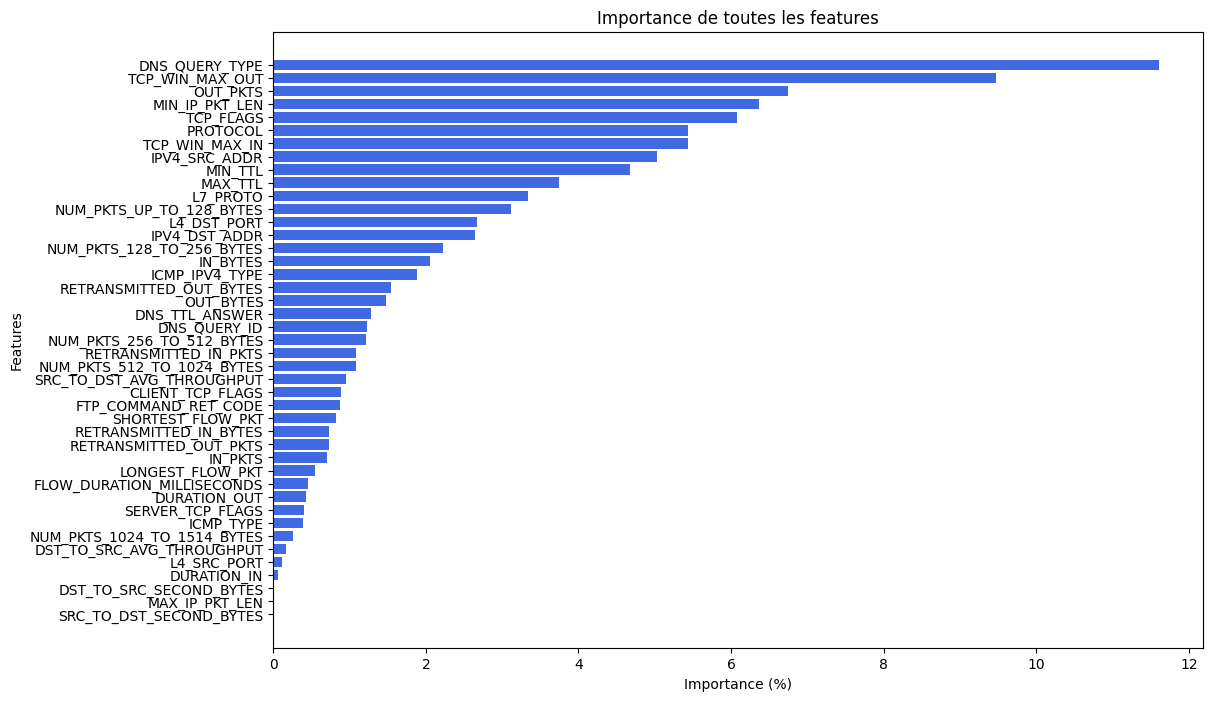

In [5]:
# Charger le modèle sauvegardé
xgb_model_loaded = joblib.load("../../Balance/SaveModels/xgboost_modelv1.pkl")
print("\n✅ Modèle XGBoost chargé avec succès !")

# Vérifier l'importance des features
feature_importance = xgb_model_loaded.feature_importances_

# Convertir en pourcentage
feature_importance_percent = 100 * (feature_importance / feature_importance.sum())

# Créer un DataFrame
feat_importance_df = pd.DataFrame({
    'Feature': X_train.columns,  # Vérifie que X_train.columns est bien défini
    'Importance (%)': feature_importance_percent
}).sort_values(by='Importance (%)', ascending=False)

# Afficher toutes les features
print("\n🔍 Importance de toutes les features :\n", feat_importance_df)

# Tracer un graphique pour toutes les features
plt.figure(figsize=(12, 8))
plt.barh(feat_importance_df['Feature'], feat_importance_df['Importance (%)'], color='royalblue')
plt.xlabel("Importance (%)")
plt.ylabel("Features")
plt.title("Importance de toutes les features")
plt.gca().invert_yaxis()  # Pour afficher la plus importante en haut
plt.show()


In [6]:
# Liste des colonnes à supprimer
features_to_drop = ['DST_TO_SRC_SECOND_BYTES', 'MAX_IP_PKT_LEN', 'SRC_TO_DST_SECOND_BYTES']

# Supprimer ces colonnes de X_train et X_test
X_train_2 = X_train.drop(columns=features_to_drop, errors='ignore')
X_test_2 = X_test.drop(columns=features_to_drop, errors='ignore')


print(f"\n🚀 Features supprimées : {features_to_drop}")
print(f"✅ Nouvelle forme de X_train : {X_train_2.shape}")



🚀 Features supprimées : ['DST_TO_SRC_SECOND_BYTES', 'MAX_IP_PKT_LEN', 'SRC_TO_DST_SECOND_BYTES']
✅ Nouvelle forme de X_train : (7140000, 40)


In [7]:
# Appliquer le MinMaxScaler
scaler1 = MinMaxScaler()
X_train_scaled = scaler1.fit_transform(X_train)
X_test_scaled = scaler1.transform(X_test)
# Sauvegarde du scaler
joblib.dump(scaler1, "../SaveSclaer/scalerXGboost_FeatImportance.joblib")

['../SaveSclaer/scalerXGboost_FeatImportance.joblib']

In [8]:
# Initialiser le modèle avec les mêmes paramètres
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(set(y_train)),
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    n_estimators=457,
    max_depth=8,
    learning_rate=0.19289
)

# Entraîner avec les nouvelles données
xgb_model.fit(X_train_scaled, y_train)

print("\n✅ Modèle réentraîné avec les features sélectionnées !")


c:\Users\T U F\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [09:56:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



✅ Modèle réentraîné avec les features sélectionnées !


In [10]:
# 🎯 1. Prédiction
y_pred = xgb_model.predict(X_test_scaled)
y_proba = xgb_model.predict_proba(X_test_scaled)

# ✅ 2. Métriques globales
accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
mcc = matthews_corrcoef(y_test, y_pred)

# 🔍 3. Calcul du FAR (False Alarm Rate) / FPR (False Positive Rate)
cm = confusion_matrix(y_test, y_pred)
FP = cm.sum(axis=0) - np.diag(cm)  # Faux positifs
TN = cm.sum() - (FP + cm.sum(axis=1) - np.diag(cm) + np.diag(cm))  # Vrais négatifs
FPR = (FP / (FP + TN)).mean()  # Moyenne pour toutes les classes

# 📊 4. ROC-AUC Score (si applicable)
try:
    roc_auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
except ValueError:
    roc_auc = "N/A (Classe unique ou problème de probabilité)"

# 🔢 5. Affichage des métriques
print(f"✅ Accuracy : {accuracy:.4f}")
print(f"🎯 Precision : {precision:.4f}")
print(f"🔁 Recall : {recall:.4f}")
print(f"⚡ F1-Score : {f1:.4f}")
print(f"🚨 FAR / FPR : {FPR:.4f}")
print(f"📈 ROC-AUC Score : {roc_auc}")
print(f"🧩 Matthews Correlation Coefficient (MCC) : {mcc:.4f}")




✅ Accuracy : 0.9818
🎯 Precision : 0.9856
🔁 Recall : 0.9818
⚡ F1-Score : 0.9825
🚨 FAR / FPR : 0.0009
📈 ROC-AUC Score : 0.9993295794058569
🧩 Matthews Correlation Coefficient (MCC) : 0.9810


In [11]:
joblib.dump(xgb_model, "../../Balance/SaveModels/xgboost_modelv2.pkl")
print("\n💾 Modèle sauvegardé sous 'xgboost_modelv2.pkl'.")



💾 Modèle sauvegardé sous 'xgboost_modelv2.pkl'.


Adaboost *********************

In [ ]:
# Initialiser le modèle AdaBoost avec un arbre de décision comme estimateur de base
adaboost_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),  # Arbre de décision faible
    n_estimators=1000,  # Nombre d'estimateurs
    learning_rate=1.0,
    random_state=42
)

# Entraîner le modèle
adaboost_model.fit(X_train_scaled, y_train)
print("\n✅ Modèle AdaBoost entraîné avec succès !")


✅ Modèle AdaBoost entraîné avec succès !


In [ ]:
# 🎯 1. Prédiction
y_pred = adaboost_model.predict(X_test_scaled)
y_proba =adaboost_model.predict_proba(X_test_scaled)

# ✅ 2. Métriques globales
accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
mcc = matthews_corrcoef(y_test, y_pred)

# 🔍 3. Calcul du FAR (False Alarm Rate) / FPR (False Positive Rate)
cm = confusion_matrix(y_test, y_pred)
FP = cm.sum(axis=0) - np.diag(cm)  # Faux positifs
TN = cm.sum() - (FP + cm.sum(axis=1) - np.diag(cm) + np.diag(cm))  # Vrais négatifs
FPR = (FP / (FP + TN)).mean()  # Moyenne pour toutes les classes

# 📊 4. ROC-AUC Score (si applicable)
try:
    roc_auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
except ValueError:
    roc_auc = "N/A (Classe unique oua problème de probabilité)"

# 🔢 5. Affichage des métriques
print(f"✅ Accuracy : {accuracy:.4f}")
print(f"🎯 Precision : {precision:.4f}")
print(f"🔁 Recall : {recall:.4f}")
print(f"⚡ F1-Score : {f1:.4f}")
print(f"🚨 FAR / FPR : {FPR:.4f}")
print(f"📈 ROC-AUC Score : {roc_auc}")
print(f"🧩 Matthews Correlation Coefficient (MCC) : {mcc:.4f}")




c:\Users\T U F\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


✅ Accuracy : 0.4777
🎯 Precision : 0.5482
🔁 Recall : 0.4777
⚡ F1-Score : 0.4249
🚨 FAR / FPR : 0.0261
📈 ROC-AUC Score : 0.9631101994015326
🧩 Matthews Correlation Coefficient (MCC) : 0.4711


In [ ]:
joblib.dump(adaboost_model, "../../Balance/SaveModels/adaboost_modelv1.pkl")
print("\n💾 Modèle sauvegardé sous adaboost_modelv1.pkl'.")



💾 Modèle sauvegardé sous adaboost_modelv1.pkl'.


In [4]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt

# Charger le modèle AdaBoost sauvegardé
adaboost_model = joblib.load("../../Balance/SaveModels/adaboost_modelv1.pkl")
print("\n✅ Modèle AdaBoost chargé avec succès !")

# Vérifier l'importance des features
feature_importance = adaboost_model.feature_importances_

# Convertir en pourcentage
feature_importance_percent = 100 * (feature_importance / feature_importance.sum())

# Créer un DataFrame
feat_importance_df = pd.DataFrame({
    'Feature': X_train.columns,  # Vérifie que X_train.columns est bien défini
    'Importance (%)': feature_importance_percent
}).sort_values(by='Importance (%)', ascending=False)

# Afficher toutes les features
print("\n🔍 Importance de toutes les features :\n", feat_importance_df)

# Tracer un graphique pour toutes les features
plt.figure(figsize=(12, 8))
plt.barh(feat_importance_df['Feature'], feat_importance_df['Importance (%)'], color='royalblue')
plt.xlabel("Importance (%)")
plt.ylabel("Features")
plt.title("Importance de toutes les features - AdaBoost")
plt.gca().invert_yaxis()  # Pour afficher la plus importante en haut
plt.show()



✅ Modèle AdaBoost chargé avec succès !


ValueError: All arrays must be of the same length

In [5]:
# Liste des colonnes à supprimer
features_to_drop = ['OUT_PKTS', 'ICMP_IPV4_TYPE', 'ICMP_TYPE','DNS_TTL_ANSWER','FTP_COMMAND_RET_CODE']

# Supprimer ces colonnes de X_train et X_test
X_train_2 = X_train.drop(columns=features_to_drop, errors='ignore')
X_test_2 = X_test.drop(columns=features_to_drop, errors='ignore')


print(f"\n🚀 Features supprimées : {features_to_drop}")
print(f"✅ Nouvelle forme de X_train : {X_train_2.shape}")



🚀 Features supprimées : ['OUT_PKTS', 'ICMP_IPV4_TYPE', 'ICMP_TYPE', 'DNS_TTL_ANSWER', 'FTP_COMMAND_RET_CODE']
✅ Nouvelle forme de X_train : (7140000, 40)


In [6]:
scaler = MinMaxScaler()
X_train_scaled2 = scaler.fit_transform(X_train_2)
X_test_scaled2 = scaler.transform(X_test_2)

In [7]:
# Sauvegarde du scaler
joblib.dump(scaler, "../SaveSclaer/scalerAdab_featSelect.joblib")

['../SaveSclaer/scalerAdab_featSelect.joblib']

In [8]:
# Initialiser le modèle AdaBoost avec un arbre de décision comme estimateur de base
adaboost_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),  # Arbre de décision faible
    n_estimators=1000,  # Nombre d'estimateurs
    learning_rate=1.0,
    random_state=42
)

# Entraîner le modèle
adaboost_model.fit(X_train_scaled2, y_train)
print("\n✅ Modèle AdaBoost entraîné avec succès !")


✅ Modèle AdaBoost entraîné avec succès !


In [ ]:
 
print(f"✅ Accuracy : {accuracy:.4f}")
print(f"🎯 Precision : {precision:.4f}")
print(f"🔁 Recall : {recall:.4f}")
print(f"⚡ F1-Score : {f1:.4f}")
print(f"🚨 FAR / FPR : {FPR:.4f}")
print(f"📈 ROC-AUC Score : {roc_auc}")
print(f"🧩 Matthews Correlation Coefficient (MCC) : {mcc:.4f}")




c:\Users\T U F\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


✅ Accuracy : 0.4902
🎯 Precision : 0.3974
🔁 Recall : 0.4902
⚡ F1-Score : 0.4126
🚨 FAR / FPR : 0.0255
📈 ROC-AUC Score : 0.940569378437232
🧩 Matthews Correlation Coefficient (MCC) : 0.4966


In [11]:
joblib.dump(adaboost_model, "../../Balance/SaveModels/adaboost_modelv2.pkl")
print("\n💾 Modèle sauvegardé sous adaboost_modelv2.pkl'.")


💾 Modèle sauvegardé sous adaboost_modelv2.pkl'.


In [6]:
# Initialiser le modèle de Régression Logistique avec la pénalité et C=10
log_reg_model = LogisticRegression(
    penalty='l2',  # Pénalité L2 (par défaut avec lbfgs)
    C=10,  # Valeur de régularisation
    max_iter=1000,  # Nombre d'itérations pour la convergence
    solver='lbfgs',  # Algorithme d'optimisation
    random_state=42
)

# Entraîner le modèle
log_reg_model.fit(X_train_scaled, y_train)
print("\n✅ Modèle de Régression Logistique entraîné avec succès!")



✅ Modèle de Régression Logistique entraîné avec succès!


c:\Users\T U F\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# 🎯 1. Prédiction
y_pred = log_reg_model.predict(X_test_scaled)
y_proba = log_reg_model.predict_proba(X_test_scaled)

# ✅ 2. Métriques globales
accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
mcc = matthews_corrcoef(y_test, y_pred)

# 🔍 3. Calcul du FAR (False Alarm Rate) / FPR (False Positive Rate)
cm = confusion_matrix(y_test, y_pred)
FP = cm.sum(axis=0) - np.diag(cm)  # Faux positifs
TN = cm.sum() - (FP + cm.sum(axis=1) - np.diag(cm) + np.diag(cm))  # Vrais négatifs
FPR = (FP / (FP + TN)).mean()  # Moyenne pour toutes les classes

# 📊 4. ROC-AUC Score (si applicable)
try:
    roc_auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
except ValueError:
    roc_auc = "N/A (Classe unique ou problème de probabilité)"

# 🔢 5. Affichage des métriques
print(f"✅ Accuracy : {accuracy:.4f}")
print(f"🎯 Precision : {precision:.4f}")
print(f"🔁 Recall : {recall:.4f}")

print(f"⚡ F1-Score : {f1:.4f}")
print(f"🚨 FAR / FPR : {FPR:.4f}")
print(f"📈 ROC-AUC Score : {roc_auc}")
print(f"🧩 Matthews Correlation Coefficient (MCC) : {mcc:.4f}")



✅ Accuracy : 0.8752
🎯 Precision : 0.8818
🔁 Recall : 0.8752
⚡ F1-Score : 0.8747
🚨 FAR / FPR : 0.0062
📈 ROC-AUC Score : 0.9935340237508958
🧩 Matthews Correlation Coefficient (MCC) : 0.8694


In [9]:
joblib.dump(log_reg_model, "../../Balance/SaveModels/log_reg_modelv1.pkl")
print("\n💾 Modèle sauvegardé sous log_reg_modelv1.pkl'.")


💾 Modèle sauvegardé sous log_reg_modelv1.pkl'.


In [10]:
# Initialiser le modèle MLP (Multi-Layer Perceptron)
mlp_model = MLPClassifier(
    hidden_layer_sizes=(100,),  # Une couche cachée de 100 neurones
    activation='relu',  # Fonction d'activation
    solver='adam',  # Algorithme d'optimisation
    max_iter=500,  # Nombre d'itérations pour la convergence
    random_state=42
)

# Entraîner le modèle
mlp_model.fit(X_train_scaled, y_train)
print("\n✅ Modèle MLP entraîné avec succès !")


✅ Modèle MLP entraîné avec succès !


In [11]:
# 🎯 1. Prédiction
y_pred = mlp_model.predict(X_test_scaled)
y_proba = mlp_model.predict_proba(X_test_scaled)

# ✅ 2. Métriques globales
accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
mcc = matthews_corrcoef(y_test, y_pred)

# 🔍 3. Calcul du FAR (False Alarm Rate) / FPR (False Positive Rate)
cm = confusion_matrix(y_test, y_pred)
FP = cm.sum(axis=0) - np.diag(cm)  # Faux positifs
TN = cm.sum() - (FP + cm.sum(axis=1) - np.diag(cm) + np.diag(cm))  # Vrais négatifs
FPR = (FP / (FP + TN)).mean()  # Moyenne pour toutes les classes

# 📊 4. ROC-AUC Score (si applicable)
try:
    roc_auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
except ValueError:
    roc_auc = "N/A (Classe unique ou problème de probabilité)"

# 🔢 5. Affichage des métriques
print(f"✅ Accuracy : {accuracy:.4f}")
print(f"🎯 Precision : {precision:.4f}")
print(f"🔁 Recall : {recall:.4f}")
print(f"⚡ F1-Score : {f1:.4f}")
print(f"🚨 FAR / FPR : {FPR:.4f}")
print(f"📈 ROC-AUC Score : {roc_auc}")
print(f"🧩 Matthews Correlation Coefficient (MCC) : {mcc:.4f}")



✅ Accuracy : 0.9608
🎯 Precision : 0.9655
🔁 Recall : 0.9608
⚡ F1-Score : 0.9613
🚨 FAR / FPR : 0.0020
📈 ROC-AUC Score : 0.9984900214911865
🧩 Matthews Correlation Coefficient (MCC) : 0.9591


In [12]:
joblib.dump(mlp_model, "../../Balance/SaveModels/mlp_modelv1.pkl")
print("\n💾 Modèle sauvegardé sous mlp_modelv1.pkl'.")


💾 Modèle sauvegardé sous mlp_modelv1.pkl'.


In [14]:
# Construire le modèle DNN (Deep Neural Network)
dnn_model = keras.Sequential([
    keras.layers.InputLayer(input_shape=(X_train_scaled.shape[1],)),
    keras.layers.Dense(128, activation='relu'),  # Première couche cachée
    keras.layers.Dense(64, activation='relu'),   # Deuxième couche cachée
    keras.layers.Dense(21, activation='softmax')  # Couche de sortie (classification multi-classes)
])

# Compiler le modèle
dnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Entraîner le modèle
dnn_model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_data=(X_test_scaled, y_test))
print("\n✅ Modèle DNN entraîné avec succès !")

Epoch 1/50
223125/223125 ━━━━━━━━━━━━━━━━━━━━ 292s 1ms/step - accuracy: 0.8988 - loss: 0.2867 - val_accuracy: 0.9477 - val_loss: 0.1585
Epoch 2/50
223125/223125 ━━━━━━━━━━━━━━━━━━━━ 276s 1ms/step - accuracy: 0.9496 - loss: 0.1519 - val_accuracy: 0.9545 - val_loss: 0.1501
Epoch 3/50
223125/223125 ━━━━━━━━━━━━━━━━━━━━ 288s 1ms/step - accuracy: 0.9545 - loss: 0.1377 - val_accuracy: 0.9595 - val_loss: 0.1338
Epoch 4/50
223125/223125 ━━━━━━━━━━━━━━━━━━━━ 288s 1ms/step - accuracy: 0.9590 - loss: 0.1286 - val_accuracy: 0.9612 - val_loss: 0.1216
Epoch 5/50
223125/223125 ━━━━━━━━━━━━━━━━━━━━ 278s 1ms/step - accuracy: 0.9608 - loss: 0.1238 - val_accuracy: 0.9609 - val_loss: 0.1247
Epoch 6/50
223125/223125 ━━━━━━━━━━━━━━━━━━━━ 285s 1ms/step - accuracy: 0.9618 - loss: 0.1218 - val_accuracy: 0.9631 - val_loss: 0.1161
Epoch 7/50
223125/223125 ━━━━━━━━━━━━━━━━━━━━ 303s 1ms/step - accuracy: 0.9626 - loss: 0.1193 - val_accuracy: 0.9644 - val_loss: 0.1161
Epoch 8/50
223125/223125 ━━━━━━━━━━━━━━━━━━━━ 29

In [ ]:
# 🎯 1. Prédiction
y_proba = dnn_model.predict(X_test_scaled)  # Probabilités des classes
y_pred = np.argmax(y_proba, axis=1)  # Conversion en labels prédits

# ✅ 2. Métriques globales
accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
mcc = matthews_corrcoef(y_test, y_pred)

# 🔍 3. Calcul du FAR (False Alarm Rate) / FPR (False Positive Rate)
cm = confusion_matrix(y_test, y_pred)
FP = cm.sum(axis=0) - np.diag(cm)  # Faux positifs
TN = cm.sum() - (FP + cm.sum(axis=1) - np.diag(cm) + np.diag(cm))  # Vrais négatifs
FPR = (FP / (FP + TN + 1e-10)).mean()  # Éviter division par zéro

# 📊 4. ROC-AUC Score (si applicable)
try:
    roc_auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
except ValueError:
    roc_auc = "N/A (Classe unique ou problème de probabilité)"

# 🔢 5. Affichage des métriques
print(f"✅ Accuracy : {accuracy:.4f}")
print(f"🎯 Precision : {precision:.4f}")
print(f"🔁 Recall : {recall:.4f}")
print(f"⚡ F1-Score : {f1:.4f}")
print(f"🚨 FAR / FPR : {FPR:.4f}")
print(f"📈 ROC-AUC Score : {roc_auc}")
print(f"🧩 Matthews Correlation Coefficient (MCC) : {mcc:.4f}")





39375/39375 ━━━━━━━━━━━━━━━━━━━━ 29s 736us/step
✅ Accuracy : 0.9573
🎯 Precision : 0.9622
🔁 Recall : 0.9573
⚡ F1-Score : 0.9581
🚨 FAR / FPR : 0.0021
📈 ROC-AUC Score : 0.9985221908464952
🧩 Matthews Correlation Coefficient (MCC) : 0.9554


In [18]:
joblib.dump(dnn_model, "../../Balance/SaveModels/dnn_modelv1.pkl")
print("\n💾 Modèle sauvegardé sous dnn_modelv1.pkl'.")


💾 Modèle sauvegardé sous dnn_modelv1.pkl'.


Optimisation Feature Selection 

In [12]:
# 📌 Importer les bibliothèques nécessaires
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, matthews_corrcoef


# 📌 Appliquer PCA
pca = PCA(n_components=0.9999)  # Garder 95% de la variance
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"🔍 Nombre de features après PCA : {X_train_pca.shape[1]}")





🔍 Nombre de features après PCA : 27


In [ ]:
# 📌 Entraîner un MLPClassifier avec les nouvelles features PCA
mlp_model = MLPClassifier(hidden_layer_sizes=(100,), activation='relu', solver='adam', max_iter=500, random_state=42)
mlp_model.fit(X_train_pca, y_train)

# 📌 Prédiction
y_pred = mlp_model.predict(X_test_pca)

# 📌 Évaluation des performances
accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
mcc = matthews_corrcoef(y_test, y_pred)

# 🔍 3. Calcul du FAR (False Alarm Rate) / FPR (False Positive Rate)
cm = confusion_matrix(y_test, y_pred)
FP = cm.sum(axis=0) - np.diag(cm)  # Faux positifs
TN = cm.sum() - (FP + cm.sum(axis=1) - np.diag(cm) + np.diag(cm))  # Vrais négatifs
FPR = (FP / (FP + TN + 1e-10)).mean()  # Éviter division par zéro







NameError: name 'y_proba' is not defined

In [11]:
# 📌 Prédictions de probabilités pour le calcul du ROC-AUC
try:
    y_pred_proba = mlp_model.predict_proba(X_test_pca)
    roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class="ovr", average="weighted")
except ValueError:
    roc_auc = "N/A (Classe unique ou problème de probabilité)"


# 🔢 5. Affichage des métriques
print(f"✅ Accuracy : {accuracy:.4f}")
print(f"🎯 Precision : {precision:.4f}")
print(f"🔁 Recall : {recall:.4f}")
print(f"⚡ F1-Score : {f1:.4f}")
print(f"🚨 FAR / FPR : {FPR:.4f}")
print(f"📈 ROC-AUC Score : {roc_auc}")
print(f"🧩 Matthews Correlation Coefficient (MCC) : {mcc:.4f}")

✅ Accuracy : 0.9607
🎯 Precision : 0.9647
🔁 Recall : 0.9607
⚡ F1-Score : 0.9611
🚨 FAR / FPR : 0.0020
📈 ROC-AUC Score : 0.998414086092103
🧩 Matthews Correlation Coefficient (MCC) : 0.9589


In [12]:
joblib.dump(mlp_model, "../../Balance/SaveModels/mlp_modelv2PCA.pkl")
print("\n💾 Modèle sauvegardé sous mlp_modelv2PCA.pkl'.")


💾 Modèle sauvegardé sous mlp_modelv2PCA.pkl'.


LSTM***************************

In [13]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, matthews_corrcoef

# ⚙️ Paramètres
num_classes = 21  # Nombre total de classes
X_train_reshaped = np.expand_dims(X_train_scaled, axis=1)  # Shape (samples, timesteps=1, features)
X_test_reshaped = np.expand_dims(X_test_scaled, axis=1)

# 1️⃣ Construire le modèle LSTM
model = Sequential([
    LSTM(100, activation='tanh', return_sequences=True, input_shape=(1, X_train_scaled.shape[1])),
    Dropout(0.2),  # Évite l'overfitting
    LSTM(50, activation='tanh', return_sequences=False),
    Dense(25, activation='relu'),
    Dense(num_classes, activation='softmax')  # 21 classes => Softmax
])

# 2️⃣ Compiler le modèle
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 3️⃣ Entraîner le modèle
model.fit(X_train_reshaped, y_train, epochs=30, batch_size=32, validation_data=(X_test_reshaped, y_test))

# 4️⃣ Faire des prédictions
y_pred_probs = model.predict(X_test_reshaped)  # Probabilités de chaque classe
y_pred = np.argmax(y_pred_probs, axis=1)  # Convertir en indices de classe

# 5️⃣ Calculer les métriques
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
mcc = matthews_corrcoef(y_test, y_pred)

# 🚨 FPR (False Positive Rate) / FAR (False Alarm Rate)
cm = confusion_matrix(y_test, y_pred)
FP = cm.sum(axis=0) - np.diag(cm)  # Faux positifs
TN = cm.sum() - (FP + cm.sum(axis=1) - np.diag(cm))  # Vrais négatifs
FPR = np.mean(FP / (FP + TN))  # Moyenne des taux de fausses alarmes

# 📈 ROC-AUC Score (multiclass → One-vs-Rest)
roc_auc = roc_auc_score(y_test, y_pred_probs, multi_class="ovr", average="weighted")

# 🔢 Affichage des métriques
print(f"✅ Accuracy : {accuracy:.4f}")
print(f"🎯 Precision : {precision:.4f}")
print(f"🔁 Recall : {recall:.4f}")
print(f"⚡ F1-Score : {f1:.4f}")
print(f"🚨 FAR / FPR : {FPR:.4f}")
print(f"📈 ROC-AUC Score : {roc_auc:.4f}")
print(f"🧩 Matthews Correlation Coefficient (MCC) : {mcc:.4f}")


c:\Users\T U F\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
223125/223125 ━━━━━━━━━━━━━━━━━━━━ 529s 2ms/step - accuracy: 0.8618 - loss: 0.3919 - val_accuracy: 0.9416 - val_loss: 0.1782
Epoch 2/30
223125/223125 ━━━━━━━━━━━━━━━━━━━━ 531s 2ms/step - accuracy: 0.9378 - loss: 0.1885 - val_accuracy: 0.9522 - val_loss: 0.1535
Epoch 3/30
223125/223125 ━━━━━━━━━━━━━━━━━━━━ 517s 2ms/step - accuracy: 0.9479 - loss: 0.1629 - val_accuracy: 0.9545 - val_loss: 0.1462
Epoch 4/30
223125/223125 ━━━━━━━━━━━━━━━━━━━━ 565s 3ms/step - accuracy: 0.9512 - loss: 0.1533 - val_accuracy: 0.9584 - val_loss: 0.1337
Epoch 5/30
223125/223125 ━━━━━━━━━━━━━━━━━━━━ 542s 2ms/step - accuracy: 0.9531 - loss: 0.1476 - val_accuracy: 0.9587 - val_loss: 0.1313
Epoch 6/30
223125/223125 ━━━━━━━━━━━━━━━━━━━━ 632s 3ms/step - accuracy: 0.9544 - loss: 0.1443 - val_accuracy: 0.9584 - val_loss: 0.1292
Epoch 7/30
223125/223125 ━━━━━━━━━━━━━━━━━━━━ 665s 3ms/step - accuracy: 0.9555 - loss: 0.1410 - val_accuracy: 0.9618 - val_loss: 0.1242
Epoch 8/30
223125/223125 ━━━━━━━━━━━━━━━━━━━━ 64

In [14]:
joblib.dump(model, "../../Balance/SaveModels/LSTMv1.pkl")
print("\n💾 Modèle sauvegardé sous LSTMv1.pkl'.")


💾 Modèle sauvegardé sous LSTMv1.pkl'.


LSTM Feature selection with PCA

In [13]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, matthews_corrcoef

# ⚙️ Paramètres
num_classes = 21  # Nombre total de classes
X_train_reshaped = np.expand_dims(X_train_pca, axis=1)  # Shape (samples, timesteps=1, features)
X_test_reshaped = np.expand_dims(X_test_pca, axis=1)

# 1️⃣ Construire le modèle LSTM
model = Sequential([
    LSTM(100, activation='tanh', return_sequences=True, input_shape=(1, X_train_pca.shape[1])),
    Dropout(0.2),  # Évite l'overfitting
    LSTM(50, activation='tanh', return_sequences=False),
    Dense(25, activation='relu'),
    Dense(num_classes, activation='softmax')  # 21 classes => Softmax
])

# 2️⃣ Compiler le modèle
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 3️⃣ Entraîner le modèle
model.fit(X_train_reshaped, y_train, epochs=30, batch_size=32, validation_data=(X_test_reshaped, y_test))

# 4️⃣ Faire des prédictions
y_pred_probs = model.predict(X_test_reshaped)  # Probabilités de chaque classe
y_pred = np.argmax(y_pred_probs, axis=1)  # Convertir en indices de classe

# 5️⃣ Calculer les métriques
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
mcc = matthews_corrcoef(y_test, y_pred)

# 🚨 FPR (False Positive Rate) / FAR (False Alarm Rate)
cm = confusion_matrix(y_test, y_pred)
FP = cm.sum(axis=0) - np.diag(cm)  # Faux positifs
TN = cm.sum() - (FP + cm.sum(axis=1) - np.diag(cm))  # Vrais négatifs
FPR = np.mean(FP / (FP + TN))  # Moyenne des taux de fausses alarmes

# 📈 ROC-AUC Score (multiclass → One-vs-Rest)
roc_auc = roc_auc_score(y_test, y_pred_probs, multi_class="ovr", average="weighted")

# 🔢 Affichage des métriques
print(f"✅ Accuracy : {accuracy:.4f}")
print(f"🎯 Precision : {precision:.4f}")
print(f"🔁 Recall : {recall:.4f}")
print(f"⚡ F1-Score : {f1:.4f}")
print(f"🚨 FAR / FPR : {FPR:.4f}")
print(f"📈 ROC-AUC Score : {roc_auc:.4f}")
print(f"🧩 Matthews Correlation Coefficient (MCC) : {mcc:.4f}")


c:\Users\T U F\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
223125/223125 ━━━━━━━━━━━━━━━━━━━━ 512s 2ms/step - accuracy: 0.8834 - loss: 0.3209 - val_accuracy: 0.9490 - val_loss: 0.1588
Epoch 2/30
223125/223125 ━━━━━━━━━━━━━━━━━━━━ 491s 2ms/step - accuracy: 0.9459 - loss: 0.1634 - val_accuracy: 0.9549 - val_loss: 0.1404
Epoch 3/30
223125/223125 ━━━━━━━━━━━━━━━━━━━━ 481s 2ms/step - accuracy: 0.9537 - loss: 0.1447 - val_accuracy: 0.9573 - val_loss: 0.1296
Epoch 4/30
223125/223125 ━━━━━━━━━━━━━━━━━━━━ 477s 2ms/step - accuracy: 0.9563 - loss: 0.1373 - val_accuracy: 0.9564 - val_loss: 0.1327
Epoch 5/30
223125/223125 ━━━━━━━━━━━━━━━━━━━━ 477s 2ms/step - accuracy: 0.9577 - loss: 0.1332 - val_accuracy: 0.9616 - val_loss: 0.1206
Epoch 6/30
223125/223125 ━━━━━━━━━━━━━━━━━━━━ 480s 2ms/step - accuracy: 0.9588 - loss: 0.1299 - val_accuracy: 0.9597 - val_loss: 0.1248
Epoch 7/30
223125/223125 ━━━━━━━━━━━━━━━━━━━━ 480s 2ms/step - accuracy: 0.9591 - loss: 0.1291 - val_accuracy: 0.9635 - val_loss: 0.1165
Epoch 8/30
223125/223125 ━━━━━━━━━━━━━━━━━━━━ 49

Epoch 1/5: 7060epoch [12:29:18,  6.37s/epoch]
Epoch 3/5: 28103epoch [5:50:59,  1.33epoch/s]

14236/39375 ━━━━━━━━━━━━━━━━━━━━ 33s 1ms/step

39375/39375 ━━━━━━━━━━━━━━━━━━━━ 47s 1ms/step
✅ Accuracy : 0.9678
🎯 Precision : 0.9723
🔁 Recall : 0.9678
⚡ F1-Score : 0.9684
🚨 FAR / FPR : 0.0015
📈 ROC-AUC Score : 0.9988
🧩 Matthews Correlation Coefficient (MCC) : 0.9664


In [18]:
joblib.dump(model, "../../Balance/SaveModels/LSTM_v2_PCA.pkl")
print("\n💾 Modèle sauvegardé sous LSTM_v2_PCA.pkl'.")


💾 Modèle sauvegardé sous LSTM_v2_PCA.pkl'.


PCA XGboost

In [16]:
# Initialiser le modèle avec les mêmes paramètres
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(set(y_train)),
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    n_estimators=457,
    max_depth=8,
    learning_rate=0.19289
)

# Entraîner avec les nouvelles données
xgb_model.fit(X_train_pca, y_train)

print("\n✅ Modèle réentraîné avec les features sélectionnées !")

# 🎯 1. Prédiction
y_pred = xgb_model.predict(X_test_pca)
y_proba = xgb_model.predict_proba(X_test_pca)

# ✅ 2. Métriques globales
accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
mcc = matthews_corrcoef(y_test, y_pred)

# 🔍 3. Calcul du FAR (False Alarm Rate) / FPR (False Positive Rate)
cm = confusion_matrix(y_test, y_pred)
FP = cm.sum(axis=0) - np.diag(cm)  # Faux positifs
TN = cm.sum() - (FP + cm.sum(axis=1) - np.diag(cm) + np.diag(cm))  # Vrais négatifs
FPR = (FP / (FP + TN)).mean()  # Moyenne pour toutes les classes

# 📊 4. ROC-AUC Score (si applicable)
try:
    roc_auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
except ValueError:
    roc_auc = "N/A (Classe unique ou problème de probabilité)"

# 🔢 5. Affichage des métriques
print(f"✅ Accuracy : {accuracy:.4f}")
print(f"🎯 Precision : {precision:.4f}")
print(f"🔁 Recall : {recall:.4f}")
print(f"⚡ F1-Score : {f1:.4f}")
print(f"🚨 FAR / FPR : {FPR:.4f}")
print(f"📈 ROC-AUC Score : {roc_auc}")
print(f"🧩 Matthews Correlation Coefficient (MCC) : {mcc:.4f}")





c:\Users\T U F\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [22:26:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



✅ Modèle réentraîné avec les features sélectionnées !
✅ Accuracy : 0.9799
🎯 Precision : 0.9840
🔁 Recall : 0.9799
⚡ F1-Score : 0.9807
🚨 FAR / FPR : 0.0010
📈 ROC-AUC Score : 0.9992318480081795
🧩 Matthews Correlation Coefficient (MCC) : 0.9791


In [19]:
joblib.dump(xgb_model, "../../Balance/SaveModels/XGboost_v1.2_PCA.pkl")
print("\n💾 Modèle sauvegardé sous XGboost_v1.2_PCA.pkl'.")


💾 Modèle sauvegardé sous XGboost_v1.2_PCA.pkl'.


PCA DNN

In [21]:
# Construire le modèle DNN (Deep Neural Network)
dnn_model = keras.Sequential([
    keras.layers.InputLayer(input_shape=(X_train_pca.shape[1],)),
    keras.layers.Dense(128, activation='relu'),  # Première couche cachée
    keras.layers.Dense(64, activation='relu'),   # Deuxième couche cachée
    keras.layers.Dense(21, activation='softmax')  # Couche de sortie (classification multi-classes)
])

# Compiler le modèle
dnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Entraîner le modèle
dnn_model.fit(X_train_pca, y_train, epochs=50, batch_size=32, validation_data=(X_test_pca, y_test))
print("\n✅ Modèle DNN entraîné avec succès !")


# 🎯 1. Prédiction
y_proba = dnn_model.predict(X_test_pca)  # Probabilités des classes
y_pred = np.argmax(y_proba, axis=1)  # Conversion en labels prédits

# ✅ 2. Métriques globales
accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
mcc = matthews_corrcoef(y_test, y_pred)

# 🔍 3. Calcul du FAR (False Alarm Rate) / FPR (False Positive Rate)
cm = confusion_matrix(y_test, y_pred)
FP = cm.sum(axis=0) - np.diag(cm)  # Faux positifs
TN = cm.sum() - (FP + cm.sum(axis=1) - np.diag(cm) + np.diag(cm))  # Vrais négatifs
FPR = (FP / (FP + TN + 1e-10)).mean()  # Éviter division par zéro

# 📊 4. ROC-AUC Score (si applicable)
try:
    roc_auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
except ValueError:
    roc_auc = "N/A (Classe unique ou problème de probabilité)"

# 🔢 5. Affichage des métriques
print(f"✅ Accuracy : {accuracy:.4f}")
print(f"🎯 Precision : {precision:.4f}")
print(f"🔁 Recall : {recall:.4f}")
print(f"⚡ F1-Score : {f1:.4f}")
print(f"🚨 FAR / FPR : {FPR:.4f}")
print(f"📈 ROC-AUC Score : {roc_auc}")
print(f"🧩 Matthews Correlation Coefficient (MCC) : {mcc:.4f}")

c:\Users\T U F\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/50
223125/223125 ━━━━━━━━━━━━━━━━━━━━ 327s 1ms/step - accuracy: 0.9044 - loss: 0.2701 - val_accuracy: 0.9537 - val_loss: 0.1451
Epoch 2/50
223125/223125 ━━━━━━━━━━━━━━━━━━━━ 327s 1ms/step - accuracy: 0.9524 - loss: 0.1464 - val_accuracy: 0.9600 - val_loss: 0.1301
Epoch 3/50
223125/223125 ━━━━━━━━━━━━━━━━━━━━ 300s 1ms/step - accuracy: 0.9583 - loss: 0.1319 - val_accuracy: 0.9581 - val_loss: 0.1324
Epoch 4/50
223125/223125 ━━━━━━━━━━━━━━━━━━━━ 313s 1ms/step - accuracy: 0.9604 - loss: 0.1260 - val_accuracy: 0.9624 - val_loss: 0.1194
Epoch 5/50
223125/223125 ━━━━━━━━━━━━━━━━━━━━ 347s 2ms/step - accuracy: 0.9613 - loss: 0.1234 - val_accuracy: 0.9633 - val_loss: 0.1193
Epoch 6/50
223125/223125 ━━━━━━━━━━━━━━━━━━━━ 307s 1ms/step - accuracy: 0.9623 - loss: 0.1206 - val_accuracy: 0.9611 - val_loss: 0.1222
Epoch 7/50
223125/223125 ━━━━━━━━━━━━━━━━━━━━ 297s 1ms/step - accuracy: 0.9631 - loss: 0.1186 - val_accuracy: 0.9620 - val_loss: 0.1208
Epoch 8/50
223125/223125 ━━━━━━━━━━━━━━━━━━━━ 28

In [22]:
joblib.dump(dnn_model, "../../Balance/SaveModels/dnn_model_v2_PCA.pkl")
print("\n💾 Modèle sauvegardé sous dnn_model_v2_PCA.pkl'.")


💾 Modèle sauvegardé sous dnn_model_v2_PCA.pkl'.


PCA Logistic regression

In [23]:
# Initialiser le modèle de Régression Logistique avec la pénalité et C=10
log_reg_model = LogisticRegression(
    penalty='l2',  # Pénalité L2 (par défaut avec lbfgs)
    C=10,  # Valeur de régularisation
    max_iter=1000,  # Nombre d'itérations pour la convergence
    solver='lbfgs',  # Algorithme d'optimisation
    random_state=42
)

# Entraîner le modèle
log_reg_model.fit(X_train_pca, y_train)
print("\n✅ Modèle de Régression Logistique entraîné avec succès!")

# 🎯 1. Prédiction
y_pred = log_reg_model.predict(X_test_pca)
y_proba = log_reg_model.predict_proba(X_test_pca)

# ✅ 2. Métriques globales
accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
mcc = matthews_corrcoef(y_test, y_pred)

# 🔍 3. Calcul du FAR (False Alarm Rate) / FPR (False Positive Rate)
cm = confusion_matrix(y_test, y_pred)
FP = cm.sum(axis=0) - np.diag(cm)  # Faux positifs
TN = cm.sum() - (FP + cm.sum(axis=1) - np.diag(cm) + np.diag(cm))  # Vrais négatifs
FPR = (FP / (FP + TN)).mean()  # Moyenne pour toutes les classes

# 📊 4. ROC-AUC Score (si applicable)
try:
    roc_auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
except ValueError:
    roc_auc = "N/A (Classe unique ou problème de probabilité)"

# 🔢 5. Affichage des métriques
print(f"✅ Accuracy : {accuracy:.4f}")
print(f"🎯 Precision : {precision:.4f}")
print(f"🔁 Recall : {recall:.4f}")
print(f"⚡ F1-Score : {f1:.4f}")
print(f"🚨 FAR / FPR : {FPR:.4f}")
print(f"📈 ROC-AUC Score : {roc_auc}")
print(f"🧩 Matthews Correlation Coefficient (MCC) : {mcc:.4f}")





✅ Modèle de Régression Logistique entraîné avec succès!
✅ Accuracy : 0.8846
🎯 Precision : 0.8929
🔁 Recall : 0.8846
⚡ F1-Score : 0.8848
🚨 FAR / FPR : 0.0058
📈 ROC-AUC Score : 0.9938707715590073
🧩 Matthews Correlation Coefficient (MCC) : 0.8793


In [24]:
joblib.dump(log_reg_model, "../../Balance/SaveModels/log_reg_v2_PCA.pkl")
print("\n💾 Modèle sauvegardé sous log_reg_v2_PCA.pkl'.")


💾 Modèle sauvegardé sous log_reg_v2_PCA.pkl'.


PCA ADaboost

In [25]:
# Initialiser le modèle AdaBoost avec un arbre de décision comme estimateur de base
adaboost_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),  # Arbre de décision faible
    n_estimators=1000,  # Nombre d'estimateurs
    learning_rate=1.0,
    random_state=42
)

# Entraîner le modèle
adaboost_model.fit(X_train_pca, y_train)
print("\n✅ Modèle AdaBoost entraîné avec succès !")

# 🎯 1. Prédiction
y_pred = adaboost_model.predict(X_test_pca)
y_proba =adaboost_model.predict_proba(X_test_pca)

# ✅ 2. Métriques globales
accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
mcc = matthews_corrcoef(y_test, y_pred)

# 🔍 3. Calcul du FAR (False Alarm Rate) / FPR (False Positive Rate)
cm = confusion_matrix(y_test, y_pred)
FP = cm.sum(axis=0) - np.diag(cm)  # Faux positifs
TN = cm.sum() - (FP + cm.sum(axis=1) - np.diag(cm) + np.diag(cm))  # Vrais négatifs
FPR = (FP / (FP + TN)).mean()  # Moyenne pour toutes les classes

# 📊 4. ROC-AUC Score (si applicable)
try:
    roc_auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
except ValueError:
    roc_auc = "N/A (Classe unique oua problème de probabilité)"

# 🔢 5. Affichage des métriques
print(f"✅ Accuracy : {accuracy:.4f}")
print(f"🎯 Precision : {precision:.4f}")
print(f"🔁 Recall : {recall:.4f}")
print(f"⚡ F1-Score : {f1:.4f}")
print(f"🚨 FAR / FPR : {FPR:.4f}")
print(f"📈 ROC-AUC Score : {roc_auc}")
print(f"🧩 Matthews Correlation Coefficient (MCC) : {mcc:.4f}")





✅ Modèle AdaBoost entraîné avec succès !
✅ Accuracy : 0.5859
🎯 Precision : 0.5864
🔁 Recall : 0.5859
⚡ F1-Score : 0.5496
🚨 FAR / FPR : 0.0207
📈 ROC-AUC Score : 0.9619310660113739
🧩 Matthews Correlation Coefficient (MCC) : 0.5695


In [26]:
joblib.dump(adaboost_model, "../../Balance/SaveModels/adaboostv2_PCA.pkl")
print("\n💾 Modèle sauvegardé sous adaboostv2_PCA.pkl'.")


💾 Modèle sauvegardé sous adaboostv2_PCA.pkl'.


In [13]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, matthews_corrcoef, confusion_matrix
from pyswarm import pso  # Librairie PSO

# ✅ Stocker l'historique des paramètres testés
historique_params = []

# ✅ Fonction objectif pour PSO
def objective(params):
    C, max_iter = params[0], int(params[1])  # Conversion des paramètres

    print(f"🔍 PSO teste : C={C:.5f}, max_iter={max_iter}")

    # Définir le modèle Logistic Regression
    log_reg_model = LogisticRegression(
        penalty='l2', 
        solver='saga',  
        C=C, 
        max_iter=max_iter,
        random_state=42
    )
    
    # Entraînement et prédiction
    log_reg_model.fit(X_train_pca, y_train)
    y_pred = log_reg_model.predict(X_test_pca)
    y_proba = log_reg_model.predict_proba(X_test_pca)

    # ✅ Calcul des métriques
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted", zero_division=1)
    recall = recall_score(y_test, y_pred, average="weighted", zero_division=1)
    f1 = f1_score(y_test, y_pred, average="weighted")
    mcc = matthews_corrcoef(y_test, y_pred)

    # ✅ Calcul du taux de fausses alertes (FPR)
    cm = confusion_matrix(y_test, y_pred)
    FP = cm.sum(axis=0) - np.diag(cm)  
    TN = cm.sum() - (FP + np.diag(cm) + cm.sum(axis=1) - np.diag(cm))  
    FPR = np.mean(FP / (FP + TN + 1e-10))  

    # ✅ Calcul du score ROC-AUC
    try:
        roc_auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
    except:
        roc_auc = 0  

    # ✅ Score combiné (fonction de coût à minimiser)
    score = (0.3 * recall) + (0.25 * f1) + (0.2 * (1 - FPR)) + (0.1 * mcc) + (0.1 * roc_auc) + (0.05 * acc)

    # ✅ Ajouter les paramètres et le score à l'historique
    historique_params.append((C, max_iter, score))

    # ✅ Affichage des meilleurs paramètres actuels
    meilleur_param = max(historique_params, key=lambda x: x[2])
    print(f"🔹 Meilleurs paramètres actuels : C={meilleur_param[0]:.5f}, max_iter={meilleur_param[1]}, score={meilleur_param[2]:.4f}\n")

    return -score  # PSO minimise la fonction objectif

# ✅ Définition des bornes pour PSO
lb = [0.0001, 100]   # Minimum : C=0.0001, max_iter=100
ub = [10, 10000]     # Maximum : C=10, max_iter=10 000

# ✅ Lancer PSO avec suivi des itérations
print("\n🚀 Début de l'optimisation avec PSO...\n")
best_params, _ = pso(objective, lb, ub, swarmsize=7, maxiter=7)

# ✅ Meilleurs hyperparamètres trouvés
top_params = max(historique_params, key=lambda x: x[2])
C_opt, max_iter_opt = top_params[0], top_params[1]

# ✅ Affichage final des résultats
print("\n✅ Optimisation terminée !")
print(f"✅ Meilleurs paramètres finaux : C={C_opt:.5f}, max_iter={max_iter_opt}")
print("\n📊 Historique des paramètres testés :")
for p in historique_params:
    print(f"C={p[0]:.5f}, max_iter={p[1]}, score={p[2]:.4f}")



🚀 Début de l'optimisation avec PSO...

🔍 PSO teste : C=6.32812, max_iter=8279
🔹 Meilleurs paramètres actuels : C=6.32812, max_iter=8279, score=0.8680

🔍 PSO teste : C=0.36570, max_iter=8813
🔹 Meilleurs paramètres actuels : C=6.32812, max_iter=8279, score=0.8680

🔍 PSO teste : C=1.66170, max_iter=6668
🔹 Meilleurs paramètres actuels : C=6.32812, max_iter=8279, score=0.8680

🔍 PSO teste : C=2.36229, max_iter=5821
🔹 Meilleurs paramètres actuels : C=6.32812, max_iter=8279, score=0.8680

🔍 PSO teste : C=1.38561, max_iter=8624
🔹 Meilleurs paramètres actuels : C=6.32812, max_iter=8279, score=0.8680

🔍 PSO teste : C=5.86677, max_iter=7245
🔹 Meilleurs paramètres actuels : C=6.32812, max_iter=8279, score=0.8680

🔍 PSO teste : C=0.06846, max_iter=8298
🔹 Meilleurs paramètres actuels : C=6.32812, max_iter=8279, score=0.8680

🔍 PSO teste : C=1.82208, max_iter=7027
🔹 Meilleurs paramètres actuels : C=6.32812, max_iter=8279, score=0.8680

🔍 PSO teste : C=0.00010, max_iter=9232
🔹 Meilleurs paramètres ac

In [14]:
# Initialiser le modèle de Régression Logistique avec la pénalité et C=10
log_reg_model = LogisticRegression(
    penalty='l2',  # Pénalité L2 (par défaut avec lbfgs)
    C=9.62554,  # Valeur de régularisation
    max_iter=8552,  # Nombre d'itérations pour la convergence
    solver='lbfgs',  # Algorithme d'optimisation
    random_state=42
)

# Entraîner le modèle
log_reg_model.fit(X_train_pca, y_train)
print("\n✅ Modèle de Régression Logistique entraîné avec succès!")

# 🎯 1. Prédiction
y_pred = log_reg_model.predict(X_test_pca)
y_proba = log_reg_model.predict_proba(X_test_pca)

# ✅ 2. Métriques globales
accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
mcc = matthews_corrcoef(y_test, y_pred)

# 🔍 3. Calcul du FAR (False Alarm Rate) / FPR (False Positive Rate)
cm = confusion_matrix(y_test, y_pred)
FP = cm.sum(axis=0) - np.diag(cm)  # Faux positifs
TN = cm.sum() - (FP + cm.sum(axis=1) - np.diag(cm) + np.diag(cm))  # Vrais négatifs
FPR = (FP / (FP + TN)).mean()  # Moyenne pour toutes les classes

# 📊 4. ROC-AUC Score (si applicable)
try:
    roc_auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
except ValueError:
    roc_auc = "N/A (Classe unique ou problème de probabilité)"

# 🔢 5. Affichage des métriques
print(f"✅ Accuracy : {accuracy:.4f}")
print(f"🎯 Precision : {precision:.4f}")
print(f"🔁 Recall : {recall:.4f}")
print(f"⚡ F1-Score : {f1:.4f}")
print(f"🚨 FAR / FPR : {FPR:.4f}")
print(f"📈 ROC-AUC Score : {roc_auc}")
print(f"🧩 Matthews Correlation Coefficient (MCC) : {mcc:.4f}")





✅ Modèle de Régression Logistique entraîné avec succès!
✅ Accuracy : 0.8177
🎯 Precision : 0.8219
🔁 Recall : 0.8177
⚡ F1-Score : 0.8138
🚨 FAR / FPR : 0.0091
📈 ROC-AUC Score : 0.987472705889951
🧩 Matthews Correlation Coefficient (MCC) : 0.8093
